## Load Knowledge Base
(resolution guides, SOPs, and supplier profiles)

In [1]:
import json

with open("../data/raw/knowledge_base.json", "r") as f:
    knowledge_base = json.load(f)

print(f"Total documents: {len(knowledge_base)}")
print("\nFirst document:")
knowledge_base[0]

Total documents: 274

First document:


{'doc_id': 'KB-00001',
 'doc_type': 'resolution_guide',
 'category': 'Delivery Delay',
 'content': 'For delivery delays, immediately contact logistics partner to track shipment location. Provide customer with updated ETA and offer 10% discount on next order if delay exceeds 3 days. Escalate to operations manager if delay is over 7 days.',
 'last_updated': '2025-04-16'}

## Wrap Documents for LangChain
Convert JSON into LangChain Document Oject

In [2]:
from langchain_core.documents import Document
# Create Document objects from the knowledge base
documents = [
    Document(
        page_content=doc["content"],
        metadata={
            "doc_id": doc["doc_id"],
            "doc_type": doc["doc_type"],
            "category": doc["category"],
            "last_updated": doc["last_updated"],
        },
    )
    for doc in knowledge_base
]

print(f"Created {len(documents)} Document objects")
documents[0]

Created 274 Document objects


Document(metadata={'doc_id': 'KB-00001', 'doc_type': 'resolution_guide', 'category': 'Delivery Delay', 'last_updated': '2025-04-16'}, page_content='For delivery delays, immediately contact logistics partner to track shipment location. Provide customer with updated ETA and offer 10% discount on next order if delay exceeds 3 days. Escalate to operations manager if delay is over 7 days.')

## Build the FAISS Index

In [ ]:
from langchain_community.embeddings import SentenceTransformerEmbeddings
from langchain_community.vectorstores import FAISS
# FAISS.from_documents() expects a LangChain-compatible embeddings object
embedding_model = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")

# Embeds all 274 documents' page_content,AND builds a searchable FAISS index out of the vectors
faiss_index = FAISS.from_documents(documents, embedding_model)

print("FAISS index built successfully")


C:\Users\mjhog\AppData\Local\Temp\ipykernel_23512\562529100.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.embeddings import SentenceTransformerEmbeddings
C:\Users\mjhog\AppData\Local\Temp\ipykernel_23512\562529100.py:7: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

FAISS index built successfully


### *Test with Samples*

In [ ]:
query = "My order arrived three days late and nobody responded to my emails"

results = faiss_index.similarity_search(query, k=3)

for i, doc in enumerate(results):
    print(f"--- Result {i+1} ---")
    print(f"Category: {doc.metadata['category']}")
    print(f"Doc type: {doc.metadata['doc_type']}")
    print(f"Content: {doc.page_content}")
    print()

--- Result 1 ---
Category: Delivery Delay
Doc type: resolution_guide
Content: For delivery delays, immediately contact logistics partner to track shipment location. Provide customer with updated ETA and offer 10% discount on next order if delay exceeds 3 days. Escalate to operations manager if delay is over 7 days.

--- Result 2 ---
Category: Missing Items
Doc type: resolution_guide
Content: For incomplete orders: 1) Confirm missing items from packing documentation, 2) Expedite shipment of missing items within 24 hours, 3) Waive shipping charges, 4) Offer 15% discount on affected items, 5) Review warehouse processes if pattern emerges.

--- Result 3 ---
Category: Delivery Delay
Doc type: resolution_guide
Content: Standard protocol for late deliveries: 1) Verify current shipment status, 2) Contact carrier for explanation, 3) Inform customer within 2 hours, 4) Offer expedited shipping on replacement if needed, 5) Apply service credit of $50-200 based on order value.



In [15]:
query2 = "The oranges I received were moldy and rotten"
results2 = faiss_index.similarity_search(query2, k=3)

for i, doc in enumerate(results2):
    print(f"--- Result {i+1} ---")
    print(f"Category: {doc.metadata['category']}")
    print(f"Content: {doc.page_content}")
    print()

--- Result 1 ---
Category: Supplier
Content: Supplier SUP-10428 - Asia Region: Specializes in oranges. Quality score: 67/100. Average delivery time: 5 days. Known issues: packaging needs improvement. Preferred for large volume orders.

--- Result 2 ---
Category: Supplier
Content: Supplier SUP-5907 - Asia Region: Specializes in oranges. Quality score: 98/100. Average delivery time: 4 days. Known issues: seasonal quality variation. Preferred for large volume orders.

--- Result 3 ---
Category: Supplier
Content: Supplier SUP-7499 - Europe Region: Specializes in oranges. Quality score: 88/100. Average delivery time: 7 days. Known issues: seasonal quality variation. Preferred for large volume orders.



### Note:
Category returned "Supplier", not one of our 8 categories from before.

In [16]:
faiss_index.save_local("../models/faiss_knowledge_base")
print("FAISS index saved.")

FAISS index saved.


## Analyze the Knowledge Base
Not all the doc types are resolution guides, this explains why "supplier" showed up before, it wasnt a resolution guide we got back from the database, it was a supplier-info doc_type

In [18]:
kb_df.groupby(["doc_type", "category"]).size()

doc_type          category           
resolution_guide  Damaged Goods            3
                  Delivery Delay           3
                  Documentation Error      3
                  Missing Items            3
                  Poor Communication       3
                  Pricing Error            3
                  Quality Issues           3
                  Service Complaint        3
sop               General                 50
supplier_info     Supplier               200
dtype: int64

<Axes: title={'center': 'Knowledge Base Documents by Type'}, xlabel='doc_type'>

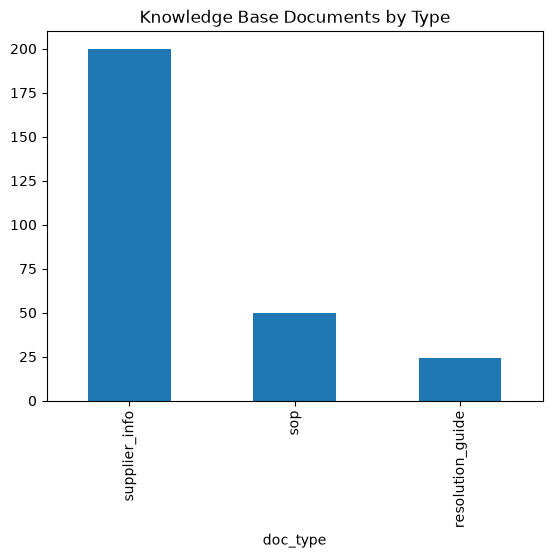

In [19]:
kb_df["doc_type"].value_counts().plot(
    kind="bar", title="Knowledge Base Documents by Type"
)

## Key Finding: Retrieval Mismatch Explained
Supplier documents make up ~73% of the knowledge base (200 of 274 documents), compared to 24 resolution guides (3 per category) and 50 SOPs. The knowledge base is mostly supplier info, and ave some of the same words as complaint queries (like the product names), so the FAISS similarity search returns supplier documents instead of resolution guides. This is a limitation of the current knowledge base, not a retrieval bug.


## Fix:
pull 15 instead of 3 documents to try and get more doctypes in the result, one of each 

In [5]:
from src.rag.retrieve import retrieve_relevant_documents

state = {"complaint_text": "The oranges I received were moldy and rotten"}
state = retrieve_relevant_documents(state)

for doc in state["retrieved_documents"]:
    print(f"{doc['doc_type']:<18} score={doc['score']:.3f}  {doc['content'][:70]}")

Retrieval took 0.02 seconds
supplier_info      score=0.903  Supplier SUP-10428 - Asia Region: Specializes in oranges. Quality scor


In [2]:
print(len(state["retrieved_documents"]))
for doc in state["retrieved_documents"]:
    print(f"{doc['doc_type']:<18} score={doc['score']:.3f}  {doc['content'][:70]}")

1
supplier_info      score=0.903  Supplier SUP-10428 - Asia Region: Specializes in oranges. Quality scor


In [4]:
from src.rag.retrieve import faiss_index

query = "The oranges I received were moldy and rotten"
results = faiss_index.similarity_search_with_score(query, k=274)

seen_types = set()
for rank, (doc, score) in enumerate(results, start=1):
    doc_type = doc.metadata.get("doc_type", "unknown")
    if doc_type not in seen_types:
        seen_types.add(doc_type)
        print(f"First {doc_type:<18} at rank {rank}, score={score:.3f}")\
            

First supplier_info      at rank 1, score=0.903
First resolution_guide   at rank 37, score=1.523
First sop                at rank 81, score=1.601


## Note:

since this was able to search through the whole knowledgebase that fast we can just have the RAG return all of them k=274

The Communicator will now always get an SOP to work with, but it might be a weakly related one, not a strongly matched one. That's the tradeoff of this fix, it solves "zero guidance," not "perfect guidance." 

In [6]:
from src.rag.retrieve import retrieve_relevant_documents

state = {"complaint_text": "The oranges I received were moldy and rotten"}
state = retrieve_relevant_documents(state)

print(len(state["retrieved_documents"]))
for doc in state["retrieved_documents"]:
    print(f"{doc['doc_type']:<18} score={doc['score']:.3f}  {doc['content'][:70]}")

Retrieval took 0.01 seconds
1
supplier_info      score=0.903  Supplier SUP-10428 - Asia Region: Specializes in oranges. Quality scor
